# Tugas 7 | Analisis PageRank Dataset web-google

1. Graph (Directed)
2. Jumlah node & edge
3. Visualisasi sebagian graph
4. 5 Node dengan PageRank tertinggi

- Dataset ini berisi pasangan (FromNodeId, ToNodeId)
- yang merepresentasikan arah tautan antar halaman web.

### import library

In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
# Baca dataset dengan mengabaikan baris komentar (yang diawali '#')
df_web = pd.read_csv("web-Google.txt", sep='\t', comment='#', names=['FromNodeId', 'ToNodeId'])
df_web

,FromNodeId,ToNodeId
0,0,11342
1,0,824020
2,0,867923
3,0,891835
4,11342,0
...,...,...
78318,495600,271199
78319,495600,407927
78320,495600,555924
78321,495600,628974


In [3]:
# Buat directed graph menggunakan NetworkX
G_web = nx.DiGraph()
G_web.add_edges_from(zip(df_web['FromNodeId'], df_web['ToNodeId']))

print(f"Jumlah Node: {G_web.number_of_nodes()}")
print(f"Jumlah Edge: {G_web.number_of_edges()}")

Jumlah Node: 10000
Jumlah Edge: 78323


In [4]:
# Hitung PageRank
pagerank_web = nx.pagerank(G_web)

# Urutkan node berdasarkan nilai PageRank
sorted_pr_web = sorted(pagerank_web.items(), key=lambda x: x[1], reverse=True)

print("\n5 Node dengan PageRank tertinggi:")
for node, score in sorted_pr_web[:5]:
    print(f"Node {node}: {score}")


5 Node dengan PageRank tertinggi:
Node 486980: 0.006515404427077107
Node 285814: 0.004632753166876134
Node 226374: 0.003301453419813612
Node 163075: 0.0032880956215481367
Node 555924: 0.002756058619751608


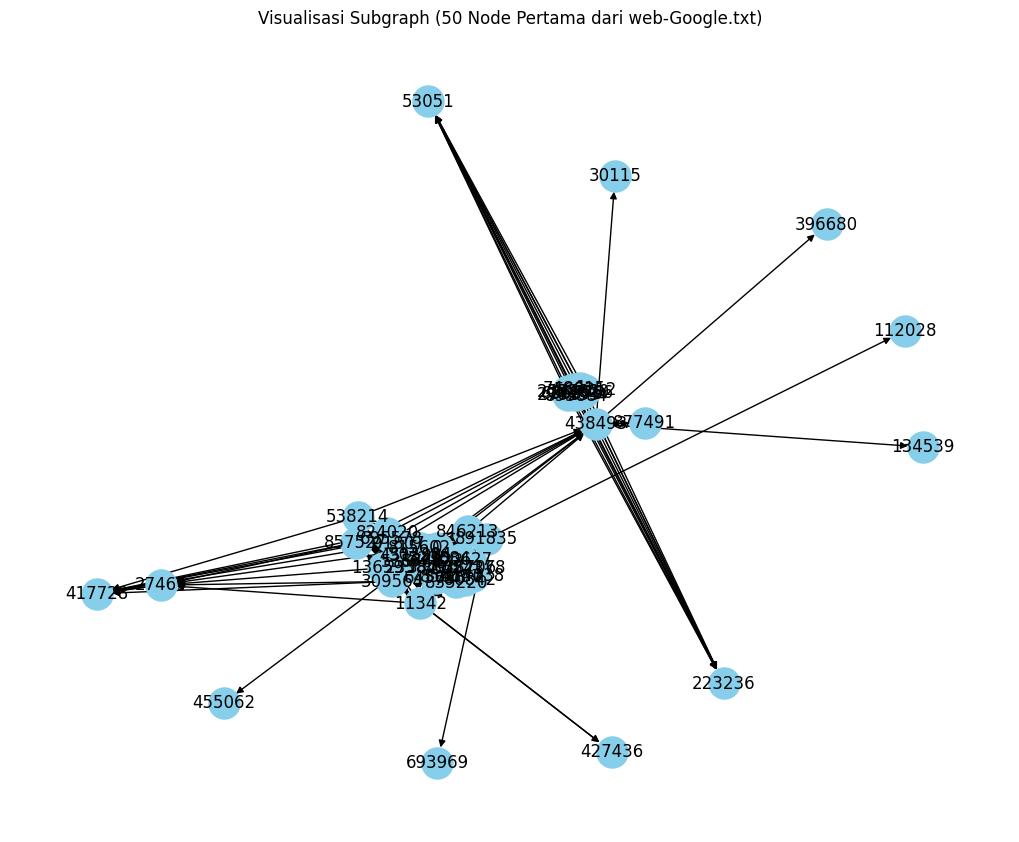

In [5]:
# Visualisasi sebagian graph (misal 50 node pertama)
plt.figure(figsize=(10,8))
sub_web = G_web.subgraph(list(G_web.nodes)[:50])
nx.draw(sub_web, with_labels=True, node_size=500, node_color='skyblue', arrows=True)
plt.title("Visualisasi Subgraph (50 Node Pertama dari web-Google.txt)")
plt.show()